# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import numpy as np
import pandas as pd
from scapy.all import raw, PcapReader, Ether

from sklearn.model_selection import train_test_split

In [2]:
raw_x_path      = "../data/tow-ids-dataset/raw/Automotive_Ethernet_with_Attack_original_10_17_19_50_training.pcap"
raw_y_path      = "../data/tow-ids-dataset/raw/y_train.csv"
number_of_bytes = 58

In [3]:
labels = pd.read_csv(raw_y_path, header=None, names=["index", "class", "label"])
labels['label'] = labels['label'].map({
    'Normal': 'Normal',
    'C_D': 'CAN DoS',
    'P_I': 'PTP Sync',
    'M_F': 'Switch MAC Flooding',
    'F_I': 'Frame Injection',
    'C_R': 'CAN Replay',
})

In [4]:
def detect_protocol_scapy(pkt):
        """Detect protocol using Scapy's layer inspection."""
        eth_type = pkt[Ether].type

        if eth_type in [2054, 35061, 8938]:
            return 'L2'

        if eth_type in [2048, 34525]:
            return 'IP_UDP'
        
        if eth_type in [33024, 8944]:
            return 'AVTP'
        
        if eth_type in [35063]:
            return 'PTP'
        
        return '-1'

In [5]:
def plot_img_loss(img_loss, min=None, max=None, targets=[]):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i - 0.5, color='red', linewidth=1.5, alpha=0.1)  # top edge
            plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title("Mean Image Loss Map")
    plt.tight_layout()
    plt.show()
    plt.close()

In [6]:
def load():
        """Load TOW-IDS dataset"""

        raw_x_path      = "../data/tow-ids-dataset/raw/Automotive_Ethernet_with_Attack_original_10_17_19_50_training.pcap"
        raw_y_path      = "../data/tow-ids-dataset/raw/y_train.csv"
        number_of_bytes = 50
        protocol_filter = 'AVTP'

        labels = pd.read_csv(raw_y_path, header=None, names=["pkt_idx", "class", "label"])
        labels['label'] = labels['label'].map({
            'Normal': 'Normal',
            'C_D': 'CAN DoS',
            'P_I': 'PTP Sync',
            'M_F': 'Switch MAC Flooding',
            'F_I': 'Frame Injection',
            'C_R': 'CAN Replay',
        })

        n = len(labels)
        values      = np.empty((n, number_of_bytes), dtype=np.float32)
        timestamps  = np.empty(n, dtype=object)
        protocols   = np.empty(n, dtype=object)

        with PcapReader(raw_x_path) as pcap_reader:
            for i, pkt in tqdm(enumerate(pcap_reader), total=n):
                protocol = detect_protocol_scapy(pkt)
                if (protocol_filter and (
                    (type(protocol_filter) == list and protocol not in protocol_filter) or 
                    (type(protocol_filter) != list and protocol != protocol_filter)
                    )):
                    continue

                b = raw(pkt)
                m = min(len(b), number_of_bytes)
                arr = np.frombuffer(b, dtype=np.uint8, count=m)
                if len(b) < number_of_bytes:
                    arr = np.pad(arr, (0, number_of_bytes - len(b)), 'constant')
                
                protocols[i]    = protocol
                timestamps[i]   = pkt.time
                values[i]       = arr

        values /= 255.0

        labels['timestamp'] = timestamps
        labels['protocol'] = protocols
        labels.dropna(inplace=True)

        valid_idx = labels.index
        values = values[valid_idx]

        return values, labels

In [7]:
import pickle
import torch


def save(X: np.ndarray, y: pd.DataFrame, path='sequence.pt'):
    torch.save({'X': X, 'y': y}, path, pickle_protocol=pickle.HIGHEST_PROTOCOL)

def load_sequence(path='sequence.pt'):
    cache = torch.load(path, weights_only=False)
    X, y = cache['X'], cache['y']
    return X, y

In [8]:
# byte_idx = 20
# data, labels = load()
# save(data[:, byte_idx], labels, path=f'sequence_b_{byte_idx}.pt')

In [9]:
import logging
import yaml

import sys
sys.path.append("../")

from data_pre_processing.factory import DataPreProcessingFactory
from modeling.inference.factory import ModelingInferenceFactory
from modeling.structure.factory import ModelingStructureFactory
from modeling.training.factory import ModelingTrainingFactory
from tracker.base_tracker import BaseTracker
from utils.get_device import get_device
from utils.seed_all import seed_all


DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

In [27]:
def plot_line(y_pred=None, y_true=None, name="True vs Predicted values"):
    plt.figure(figsize=(12, 6))

    # Plot true values
    if y_true is not None:
        x_true = np.arange(len(y_true))
        plt.plot(x_true, y_true, marker='x', label="True values", color="red")

        if y_pred is not None:
            # Align predictions to the *end* of true series
            start_idx = len(y_true) - len(y_pred)
            x_pred = np.arange(start_idx, start_idx + len(y_pred))
            plt.plot(x_pred, y_pred, marker='o', label="Prediction values", color="blue")
    else:
        # If no y_true, just start from 0
        x_pred = np.arange(len(y_pred))
        plt.plot(x_pred, y_pred, marker='o', label="Prediction values", color="blue")

    # Labels, title, legend
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title(name)
    plt.legend()
    plt.grid(True)
    plt.show()

# Instance

In [11]:
path = '../configs/tcn_pred.yaml'
with open(path, "r") as f:
    config = yaml.safe_load(f)

In [12]:
config['run_id'] = 'sequence_model'    
config['phase'] = 'train' # persist phase
run_id = config['run_id']

formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger('sequence_log')
logger.setLevel(logging.INFO)

console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

pre_processing = DataPreProcessingFactory().get(config, logger)

device = get_device()

model = ModelingStructureFactory().get(config, logger, device)
model.compile()

tracker = BaseTracker()

trainer = ModelingTrainingFactory().get(config, logger, device, tracker)

model_inference = ModelingInferenceFactory().get(config, logger, device)

/Users/mauriciosightman/Documents/Work/master/RABID/.venv/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


# Training

In [13]:
byte_idx = 45
values, labels = load_sequence(path=f'sequence_b_{byte_idx}.pt')

In [14]:
subset = 0.1
(X_view, starts), y = pre_processing.process(values, labels)
starts = np.random.choice(starts, size=int(subset*len(starts)), replace=False)
y = y.iloc[starts].reset_index(drop=True)
X = X_view[starts]
del X_view, starts

2025-09-22 11:56:16,513 | INFO | Class distribution:
2025-09-22 11:56:16,556 | INFO | Counter({'Normal': 225558, 'Frame Injection': 61402})


In [15]:
X = np.expand_dims(X, axis=2)

In [16]:
train_val_idx, test_idx = train_test_split(np.arange(X.shape[0]), train_size=0.8, random_state=DEFAULT_SEED, shuffle=True)

In [17]:
# 4. Execute training
logger.debug("Starting training...")
train_loss, train_val_loss = trainer.train(model, X[train_val_idx], y.iloc[train_val_idx])
logger.info(f"Training completed. Train loss: {train_loss}, Training validation loss: {train_val_loss}")

2025-09-22 11:56:18,469 | INFO | Train size: 14401, Validation size: 3601
2025-09-22 11:56:18,473 | INFO | Train labels: 
label
Normal    14401
Name: count, dtype: int64
2025-09-22 11:56:18,474 | INFO | Validation labels: 
label
Normal    3601
Name: count, dtype: int64
2025-09-22 11:56:18,495 | INFO | Running for 10 epochs
2025-09-22 11:56:18,496 | INFO | -------------------- Training started -------------------
2025-09-22 11:56:18,928 | INFO | Epoch: 0 	[0/901 (0%)]	Loss: 0.381473
2025-09-22 11:56:31,475 | INFO | Epoch: 0 	[0/226 (0%)]	Validation loss: 0.000770
2025-09-22 11:56:31,580 | INFO | Epoch: 0 	[240/226 (7%)]	Validation loss: 0.000720
2025-09-22 11:56:31,588 | INFO | Epoch: 0 	[256/226 (7%)]	Validation loss: 0.000763
2025-09-22 11:56:31,595 | INFO | Epoch: 0 	[272/226 (8%)]	Validation loss: 0.000785
2025-09-22 11:56:31,603 | INFO | Epoch: 0 	[288/226 (8%)]	Validation loss: 0.004596
2025-09-22 11:56:31,611 | INFO | Epoch: 0 	[304/226 (8%)]	Validation loss: 0.000786
2025-09-22 

In [20]:
X_test = X[test_idx]
y_test = y.iloc[test_idx].reset_index()

In [21]:
# 5. Validate
y_true, (y_pred, y_scores), val_loss = model_inference.inference(model, X[test_idx], y.iloc[test_idx])
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)
y_true['scores'] = y_scores.mean(axis=(1, 2))
y_true_benign = y_true[y_true["label"] == 'Normal']

2025-09-22 12:02:36,317 | INFO | Testing labels: 
label
Normal             4469
Frame Injection    1271
Name: count, dtype: int64
2025-09-22 12:02:36,787 | INFO | Test loss: 0.044349 	[0/5740 (0%)]


# Analyzing results

In [22]:
y_true['start_idx'][y_true['start_idx'] <= 628175].sort_values(ascending=False)

1306    627998
3928    627993
3645    627927
3858    627071
5006    627063
         ...  
1576       667
53         555
1465       441
3581       211
3904        10
Name: start_idx, Length: 2661, dtype: int64

In [26]:
y_pred[idx].shape, X_test[test_idx].squeeze((0, 2)).shape

((64, 1), (128,))

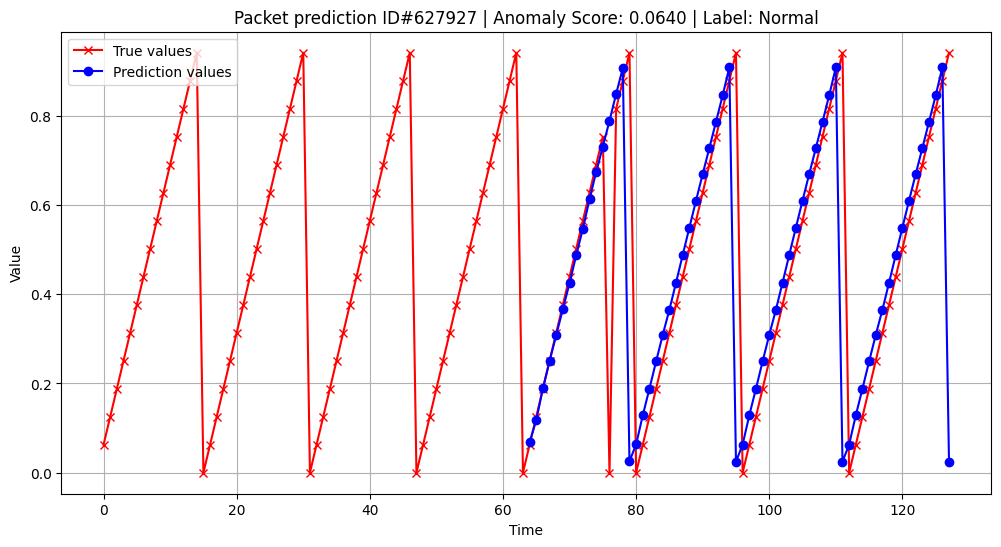

In [28]:
idx = 3645 # y_true_benign['scores'].sort_values(ascending=False).index[-12]
start_idx = y_true['start_idx'].iloc[idx]
test_idx = y_test[y_test['start_idx'] == start_idx].index
plot_line(y_pred[idx],
          y_true=X_test[test_idx].squeeze((0, 2)),
          name=f'Packet prediction ID#{start_idx} | Anomaly Score: {y_true['scores'].iloc[idx]:.4f} | Label: {y_true['label'].iloc[idx]}')

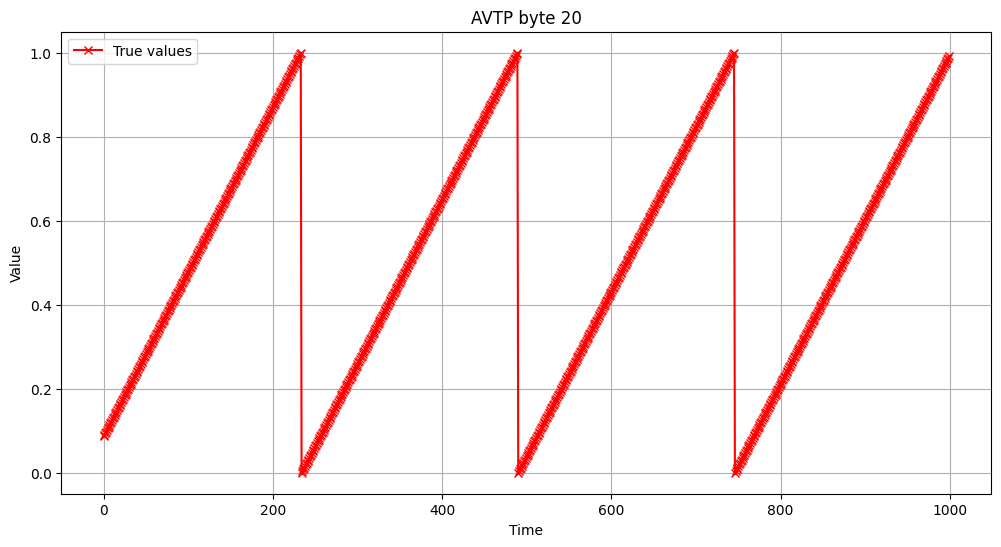

In [59]:
plot_line(y_true=values[:1000], name=f'AVTP byte 20')

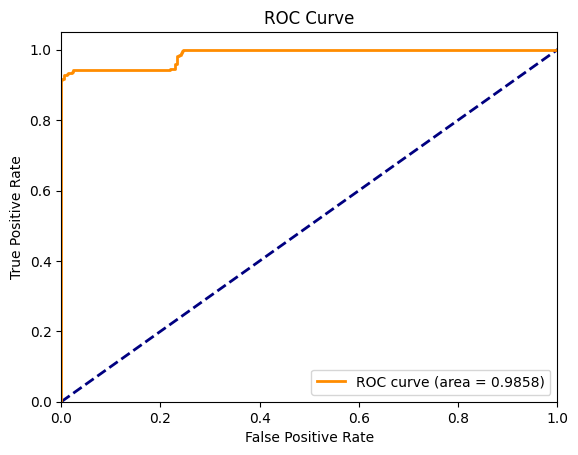

In [26]:
from sklearn.metrics import roc_auc_score, roc_curve


fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
aucroc = roc_auc_score([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
plt.figure()
plt.plot([0, 2], [0, 2], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {aucroc:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
plt.close()

In [23]:
# 53

# TCN

In [58]:
import torch.nn as nn

In [69]:
kernel_size = 2
padding     = kernel_size-1
n_inputs    = 8
n_outputs   = n_inputs
stride      = 1

net = nn.Conv1d(n_inputs, n_outputs, kernel_size, stride=stride, padding=padding)

In [70]:
x.shape

torch.Size([5, 8])

In [78]:
x = torch.tensor([
    # PKT
    [0., 0., 0., 0., 0., 0., 0., 0.],   # F
    [0., 0., 0., 0., 0., 0., 0., 0.],   # E
    [0., 0., 0., 0., 0., 0., 0., 0.],   # T
    [0., 0., 0., 0., 10., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 10.],
    ])
print(net(x[:-1, :].T)[:, :-padding].T)
print(x[:, 1:])

tensor([[-0.0841,  0.2353,  0.2052, -0.2211, -0.0294,  0.2232, -0.0456, -0.0716],
        [-0.0841,  0.2353,  0.2052, -0.2211, -0.0294,  0.2232, -0.0456, -0.0716],
        [-0.0841,  0.2353,  0.2052, -0.2211, -0.0294,  0.2232, -0.0456, -0.0716],
        [-0.3673, -0.1709, -0.0619, -0.3294, -1.9121, -0.1838,  1.5931, -0.2071]],
       grad_fn=<PermuteBackward0>)
tensor([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0., 10.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0., 10.]])


In [24]:
x[0]

tensor([ 0.,  0.,  0.,  0.,  0.,  0.,  0., 10.])

In [19]:
x = torch.tensor([
    # FEATURES
    [0., 0., 0., 0., 0.],   # P
    [0., 0., 0., 0., 0.],   # K
    [0., 0., 0., 0., 0.],   # T
    [0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0.],
    ])
print(net(x[:, :-1])[:, :-padding])
print(x[:, 1:])

NameError: name 'net' is not defined